# Part B: Modeling, plus Part C: Cross-validation

A linear-regression forecasting model for tenderloin price.

- B.1. Standardize all series. Regress tenderloin on the two top-butt cuts. Test against a constant. Examine multicollinearity by dropping a regressor and watching the condition number. Plot fit against actual.
- B.2. Hold out 2021. Train on pre-2021, predict 2021, measure out-of-sample error by horizon.
- C. A walk-forward cross-validation strategy for documenting expected accuracy, benchmarked against a naive baseline and discounted for the number of models tried.

To run, put beef_data.csv in the data/ folder and run top to bottom. The load cell cleans the data directly with the same steps as Part A and no intermediate file. Needs pandas, numpy, matplotlib, scipy, statsmodels.

In [1]:
# Install the packages below when missing, before the imports run.
import importlib, subprocess, sys

def require(pip_name, module_name=None):
    module_name = module_name or pip_name
    try:
        importlib.import_module(module_name)
    except ImportError:
        print('Installing ' + pip_name + ' ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

for _pip, _mod in [('pandas', 'pandas'), ('numpy', 'numpy'), ('matplotlib', 'matplotlib'), ('scipy', 'scipy'), ('statsmodels', 'statsmodels')]:
    require(_pip, _mod)

In [2]:
from pathlib import Path

PLOT_DIR = Path("plots")          # change this if you want them somewhere else
PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(name, fig=None, dpi=200, formats=("png",)):
    """Save the current (or given) figure into PLOT_DIR.
    Call this BEFORE plt.show() — in notebooks show() closes the figure."""
    fig = fig or plt.gcf()
    for ext in formats:
        fig.savefig(PLOT_DIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")
    return name

In [3]:
%matplotlib inline
import os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

plt.rcParams.update({'figure.dpi':110, 'font.size':11, 'axes.spines.top':False,
                     'axes.spines.right':False, 'axes.grid':True, 'grid.alpha':0.25, 'axes.axisbelow':True})
usd = FuncFormatter(lambda x, _: f"${x:,.0f}")
C = {'tndrloin':'#1b6ca8', 'butt_CC':'#d1495b', 'butt_bnls':'#2e8b57'}
pd.set_option('display.width', 160)

price_cols  = ['tndrloin_price', 'butt_CC_price', 'butt_bnls_price']
volume_cols = ['tndrloin_volume', 'butt_CC_volume', 'butt_bnls_volume']

# --- load & clean directly from the raw USDA file (identical steps to Part A) ---
RENAME = {
 'Loin, tndrloin, trmd, heavy (189A  4)_price':  'tndrloin_price',
 'Loin, top butt, CC (184B  3)_price':           'butt_CC_price',
 'Loin, top butt, bnls, heavy (184  1)_price':   'butt_bnls_price',
 'Loin, tndrloin, trmd, heavy (189A  4)_volume': 'tndrloin_volume',
 'Loin, top butt, CC (184B  3)_volume':          'butt_CC_volume',
 'Loin, top butt, bnls, heavy (184  1)_volume':  'butt_bnls_volume'}
DATA_PATH = os.path.join('data', 'beef_data.csv')
if not os.path.exists(DATA_PATH):
    for alt in ['beef_data.csv', '/mnt/project/beef_data.csv', os.path.expanduser('~/beef_data.csv')]:
        if os.path.exists(alt):
            DATA_PATH = alt
            break
df = pd.read_csv(DATA_PATH).rename(columns=RENAME)
df['report_date'] = pd.to_datetime(df['report_date'], format='%m/%d/%y')
df = df.sort_values('report_date').reset_index(drop=True)
for c in price_cols:                                   # $0 price = placeholder, not a quote
    df[c] = df[c].replace(0, np.nan)
df = df[df.report_date >= '2017-01-01'].set_index('report_date').sort_index()
df[price_cols + volume_cols] = df[price_cols + volume_cols].ffill()   # past-only, no look-ahead
df = df.reset_index()
df['year']  = df.report_date.dt.year
df['month'] = df.report_date.dt.month
print(f"Loaded & cleaned from beef_data.csv: {df.report_date.min().date()} .. {df.report_date.max().date()}  rows={len(df)}")
df.head()

Loaded & cleaned from beef_data.csv: 2017-01-06 .. 2025-06-27  rows=444


,report_date,tndrloin_price,butt_CC_price,butt_bnls_price,tndrloin_volume,butt_CC_volume,butt_bnls_volume,year,month
0,2017-01-06,930.62,371.79,242.79,616948.0,47284.0,20216.0,2017,1
1,2017-01-13,893.93,372.67,240.72,777458.0,49215.0,205260.0,2017,1
2,2017-01-20,901.44,386.83,240.39,532454.0,192155.0,83873.0,2017,1
3,2017-01-27,904.36,380.47,237.62,506527.0,127854.0,363245.0,2017,1
4,2017-02-03,898.89,406.34,255.37,524388.0,105209.0,182754.0,2017,2


## B.1 Linear regression with full history

Standardize every series to a z-score and add a _scaled suffix. One handy result: once you standardize both y and the regressors to mean 0, the OLS intercept comes out exactly 0 by construction, so the intercept carries no information here.

In [4]:
for c in price_cols + volume_cols:
    df[c + '_scaled'] = (df[c] - df[c].mean()) / df[c].std()

chk = pd.DataFrame({'scaled_mean': [df[c+'_scaled'].mean() for c in price_cols],
                    'scaled_std':  [df[c+'_scaled'].std()  for c in price_cols]}, index=price_cols)
print("Standardized price series (mean ~0, std ~1):")
print(chk.round(3).to_string())
print("\nCorrelation among the three PRICE series:")
df[price_cols].corr().round(3)

Standardized price series (mean ~0, std ~1):
                 scaled_mean  scaled_std
tndrloin_price          -0.0         1.0
butt_CC_price            0.0         1.0
butt_bnls_price          0.0         1.0

Correlation among the three PRICE series:


,tndrloin_price,butt_CC_price,butt_bnls_price
tndrloin_price,1.000,0.604,0.604
butt_CC_price,0.604,1.000,0.950
butt_bnls_price,0.604,0.950,1.000


Regress tndrloin_scaled on butt_bnls_scaled, butt_CC_scaled, and a constant.

In [5]:
y  = df['tndrloin_price_scaled']
X2 = sm.add_constant(df[['butt_bnls_price_scaled', 'butt_CC_price_scaled']])
m_full = sm.OLS(y, X2).fit()
print(m_full.summary())

Xv = sm.add_constant(df[['butt_bnls_price_scaled', 'butt_CC_price_scaled']]).values
print("\nVIF:  butt_bnls = %.2f   butt_CC = %.2f   (>10 => strong multicollinearity)"
      % (vif(Xv, 1), vif(Xv, 2)))

                              OLS Regression Results                             
Dep. Variable:     tndrloin_price_scaled   R-squared:                       0.374
Model:                               OLS   Adj. R-squared:                  0.371
Method:                    Least Squares   F-statistic:                     131.8
Date:                   Fri, 05 Jun 2026   Prob (F-statistic):           1.32e-45
Time:                           12:18:28   Log-Likelihood:                -525.47
No. Observations:                    444   AIC:                             1057.
Df Residuals:                        441   BIC:                             1069.
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

Q1. Is the model better than fitting a constant? Yes, decisively. F = 131.8, p about 1.3e-45, R-squared = 0.374. The two butt cuts jointly explain about 37% of tenderloin's standardized variance, far better than predicting the mean.

Q2. Does each regressor pass its own t-test, and does the answer contradict Q1? Both coefficients clear the 5% level at p about 0.01, but only by a hair, and their standard errors run about 3 times too wide because the two butt cuts correlate at 0.95. VIF lands near 10. No contradiction with Q1. The F-test asks whether the regressors jointly beat a constant. The t-tests ask each variable's marginal contribution given the other. They answer different questions. A model holds up as jointly strong while individual coefficients stay weak, or drop below the 5% line, under collinearity.

Note the Durbin-Watson near 0.08. The residuals are heavily positively autocorrelated, since these are trending, persistent level series. So the OLS standard errors, and the t-tests built on them, run unreliable. Part C follows the consequences.

Drop one regressor, butt_CC, and refit.

In [6]:
X1 = sm.add_constant(df[['butt_bnls_price_scaled']])
m_red = sm.OLS(y, X1).fit()
print(m_red.summary())

# side-by-side comparison (incl. the other single-regressor model)
m_red_cc = sm.OLS(y, sm.add_constant(df[['butt_CC_price_scaled']])).fit()
cmp = pd.DataFrame({
    'R2':       [m_full.rsquared,     m_red.rsquared,     m_red_cc.rsquared],
    'adj_R2':   [m_full.rsquared_adj, m_red.rsquared_adj, m_red_cc.rsquared_adj],
    'F_pvalue': [m_full.f_pvalue,     m_red.f_pvalue,     m_red_cc.f_pvalue],
    'cond_no':  [m_full.condition_number, m_red.condition_number, m_red_cc.condition_number],
}, index=['full (bnls+CC)', 'reduced (bnls)', 'reduced (CC)'])
cmp.round({'R2':3, 'adj_R2':3, 'cond_no':2})

                              OLS Regression Results                             
Dep. Variable:     tndrloin_price_scaled   R-squared:                       0.365
Model:                               OLS   Adj. R-squared:                  0.363
Method:                    Least Squares   F-statistic:                     253.6
Date:                   Fri, 05 Jun 2026   Prob (F-statistic):           1.87e-45
Time:                           12:18:28   Log-Likelihood:                -528.83
No. Observations:                    444   AIC:                             1062.
Df Residuals:                        442   BIC:                             1070.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

,R2,adj_R2,F_pvalue,cond_no
full (bnls+CC),0.374,0.371,1.320314e-45,6.24
reduced (bnls),0.365,0.363,1.867798e-45,1.00
reduced (CC),0.365,0.364,1.622968e-45,1.00


Q1. Goodness of fit after dropping a regressor? About unchanged. R-squared moves from 0.374 to 0.365 and adjusted R-squared from 0.371 to 0.363, a drop under 0.01. The dropped cut added almost nothing once you keep the other.

Q2. Coefficient strength, and the condition number? The surviving regressor grows far stronger. The t-stat jumps from 2.5 to 15.9, the standard error shrinks from 0.121 to 0.038, and p falls from 0.011 to near 0. The condition number collapses from 6.24 to 1.00, with VIF dropping from 10.25 to 1. Removing the collinear partner cost no fit and restored coefficient precision. The textbook multicollinearity remedy.

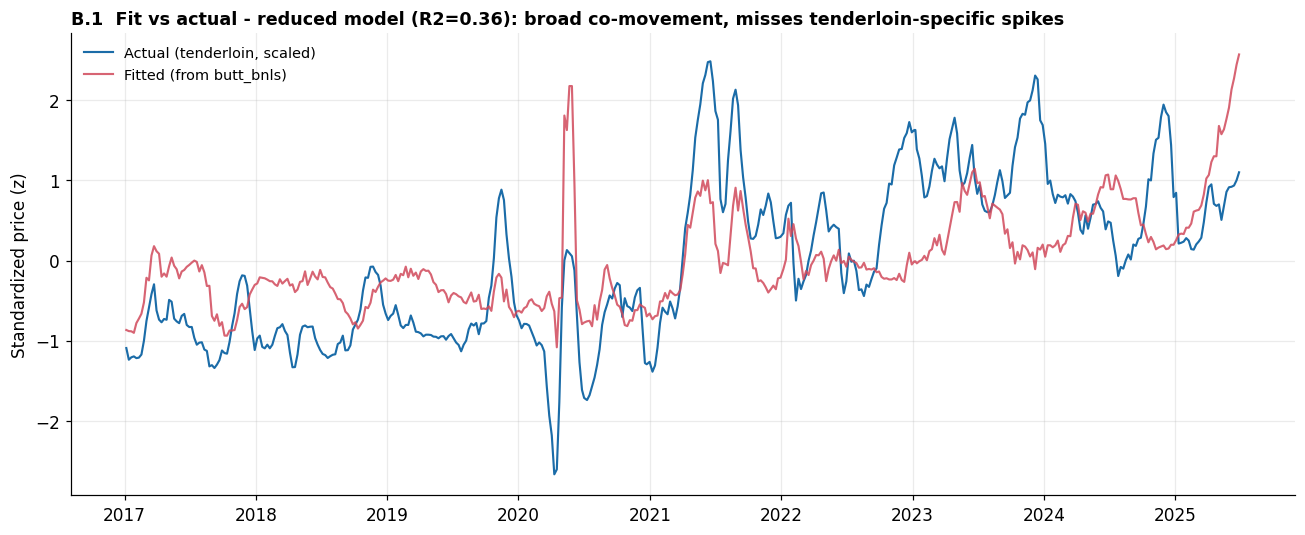

In [7]:
df['fit_scaled'] = m_red.fittedvalues
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.report_date, df.tndrloin_price_scaled, color=C['tndrloin'], lw=1.4, label='Actual (tenderloin, scaled)')
ax.plot(df.report_date, df.fit_scaled, color='#d1495b', lw=1.4, alpha=0.85, label='Fitted (from butt_bnls)')
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title(f'B.1  Fit vs actual - reduced model (R2={m_red.rsquared:.2f}): broad co-movement, misses tenderloin-specific spikes',
             fontweight='bold', fontsize=11.5, loc='left')
ax.set_ylabel('Standardized price (z)'); ax.legend(frameon=False, fontsize=9.5)
plt.tight_layout(); save_plot("B1_fit_vs_actual"); plt.show()

Fit against actual, reduced model, full sample.

## B.2 Forecasting a single holdout, 2021

Split into a train set of pre-2021 and a test set of 2021, fit OLS on train, predict 2021, and compare to actuals. Three choices worth stating.

- Model. The reduced single-regressor version, no collinearity, with fit almost identical to the full one.
- Scaling. Fit the scaler on train only and apply those numbers to the test set. Full-sample scaling would leak test information.
- Per horizon. The model is contemporaneous: predicting tenderloin in week *t* uses the same week's butt price, so it has no native multi-step horizon. That leaves two honest readings, shown in turn. **(i) An explanatory upper bound** that feeds the model 2021's realized butt prices: useful, but it quietly uses look-ahead, so its error-by-week is a ceiling, not a forecast. **(ii) A genuine forecast** that holds the information set to the end-2020 origin, random-walks the regressor forward, and reads true out-of-sample error against horizon *h* (weeks ahead).

In [8]:
# (i) EXPLANATORY upper bound - contemporaneous fit; feeds the model 2021's realized
#     butt prices, so it uses look-ahead. Treat its error as a ceiling, not a forecast.
train = df[df.report_date <  '2021-01-01'].copy()
test  = df[(df.report_date >= '2021-01-01') & (df.report_date < '2022-01-01')].copy()

muY, sdY = train.tndrloin_price.mean(), train.tndrloin_price.std()
muX, sdX = train.butt_bnls_price.mean(), train.butt_bnls_price.std()

ytr = (train.tndrloin_price - muY) / sdY
Xtr = sm.add_constant(((train.butt_bnls_price - muX) / sdX).rename('butt_bnls_scaled'))
mdl = sm.OLS(ytr, Xtr).fit()

Xte = sm.add_constant((((test.butt_bnls_price - muX) / sdX).rename('butt_bnls_scaled')), has_constant='add')
test['pred']    = mdl.predict(Xte).values * sdY + muY      # back to $/cwt with the TRAIN scaler
test['err']     = test.tndrloin_price - test.pred
test['horizon'] = np.arange(1, len(test) + 1)

rmse = np.sqrt((test.err**2).mean()); mae = test.err.abs().mean(); bias = test.err.mean()
mape = (test.err.abs() / test.tndrloin_price).mean() * 100
in_rmse = np.sqrt(((mdl.resid * sdY)**2).mean())

print(f"train: {train.report_date.min().date()}..{train.report_date.max().date()}  n={len(train)}   "
      f"test: 2021  n={len(test)}")
print(f"\nContemporaneous (explanatory upper bound) 2021:  RMSE={rmse:.0f}  MAE={mae:.0f}  MAPE={mape:.1f}%  bias=+{bias:.0f}  (USD/cwt)")
print(f"In-sample (train) residual RMSE = {in_rmse:.0f}  ->  out-of-sample is {rmse/in_rmse:.1f}x worse")
print(f"Train-period tenderloin mean = {muY:.0f};  2021 actual mean = {test.tndrloin_price.mean():.0f}  (regime jump)")

test[['report_date', 'horizon', 'tndrloin_price', 'pred', 'err']].iloc[::4].round({'tndrloin_price':0,'pred':0,'err':0})

train: 2017-01-06..2020-12-31  n=209   test: 2021  n=52

Contemporaneous (explanatory upper bound) 2021:  RMSE=398  MAE=343  MAPE=23.0%  bias=+334  (USD/cwt)
In-sample (train) residual RMSE = 112  ->  out-of-sample is 3.5x worse
Train-period tenderloin mean = 997;  2021 actual mean = 1377  (regime jump)


,report_date,horizon,tndrloin_price,pred,err
209,2021-01-08,1,856.0,960.0,-104.0
213,2021-02-05,5,1058.0,983.0,74.0
217,2021-03-05,9,1055.0,993.0,62.0
221,2021-04-02,13,1212.0,1017.0,194.0
225,2021-04-30,17,1490.0,1095.0,395.0
229,2021-05-28,21,1764.0,1136.0,627.0
233,2021-06-25,25,1771.0,1109.0,662.0
237,2021-07-23,29,1358.0,1032.0,326.0
241,2021-08-20,33,1715.0,1104.0,611.0
245,2021-09-17,37,1468.0,1101.0,367.0


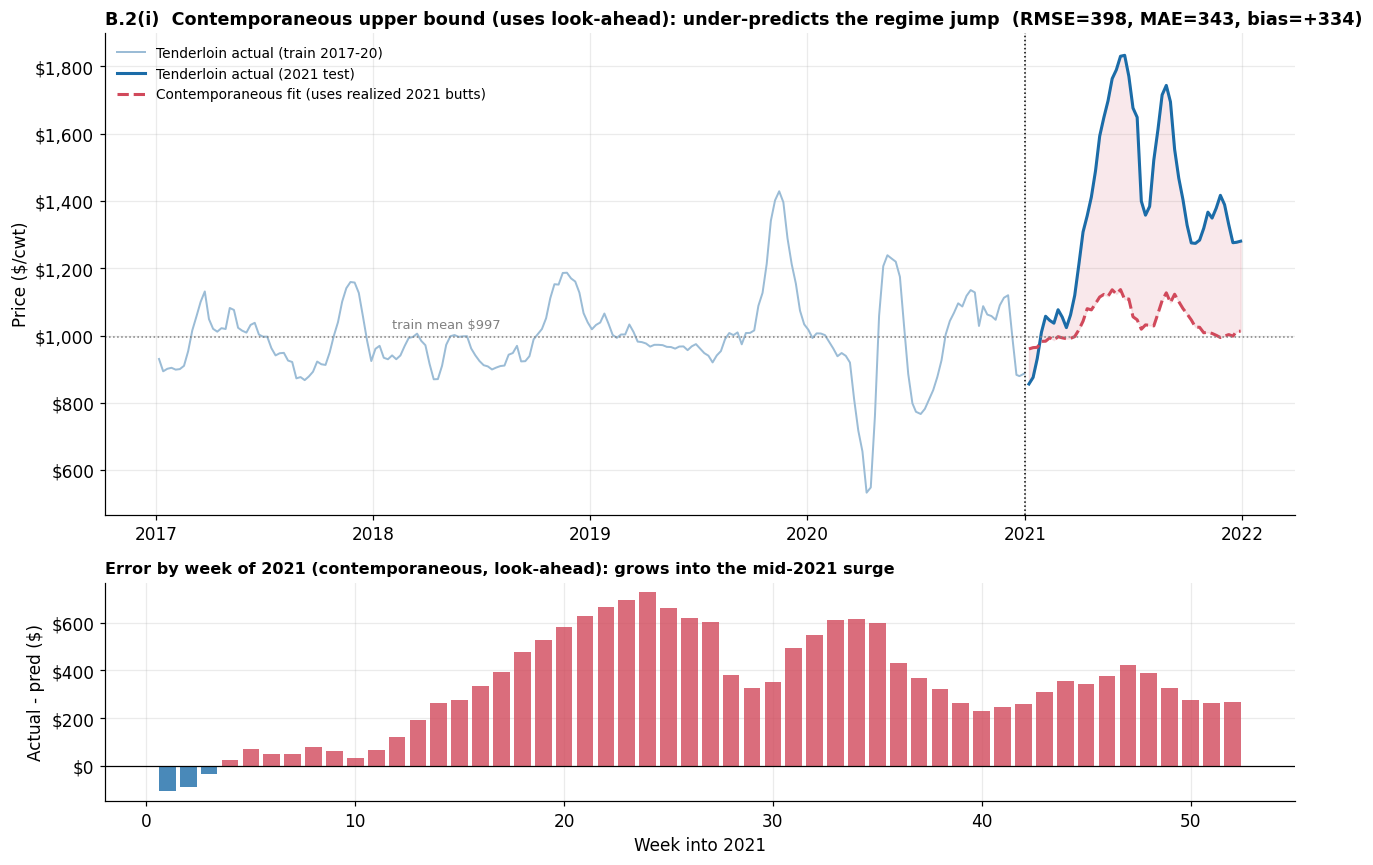

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios':[2.2, 1]})
axs[0].plot(train.report_date, train.tndrloin_price, color='#9bbcd6', lw=1.3, label='Tenderloin actual (train 2017-20)')
axs[0].plot(test.report_date,  test.tndrloin_price,  color=C['tndrloin'], lw=2.0, label='Tenderloin actual (2021 test)')
axs[0].plot(test.report_date,  test.pred, color='#d1495b', lw=2.0, ls='--', label='Contemporaneous fit (uses realized 2021 butts)')
axs[0].axvline(pd.Timestamp('2021-01-01'), color='k', ls=':', lw=1); axs[0].axhline(muY, color='grey', ls=':', lw=1)
axs[0].text(pd.Timestamp('2018-02-01'), muY + 25, f'train mean ${muY:.0f}', color='grey', fontsize=8.5)
axs[0].fill_between(test.report_date, test.pred, test.tndrloin_price, color='#d1495b', alpha=0.12)
axs[0].yaxis.set_major_formatter(usd)
axs[0].xaxis.set_major_locator(mdates.YearLocator()); axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axs[0].set_title(f'B.2(i)  Contemporaneous upper bound (uses look-ahead): under-predicts the regime jump  (RMSE={rmse:.0f}, MAE={mae:.0f}, bias=+{bias:.0f})',
                 fontweight='bold', fontsize=11.5, loc='left')
axs[0].set_ylabel('Price ($/cwt)'); axs[0].legend(frameon=False, fontsize=9, loc='upper left')

axs[1].bar(test.horizon, test.err, color=['#d1495b' if e > 0 else '#1b6ca8' for e in test.err], alpha=0.8)
axs[1].axhline(0, color='k', lw=0.8); axs[1].yaxis.set_major_formatter(usd)
axs[1].set_title('Error by week of 2021 (contemporaneous, look-ahead): grows into the mid-2021 surge', fontweight='bold', fontsize=10.5, loc='left')
axs[1].set_xlabel('Week into 2021'); axs[1].set_ylabel('Actual - pred ($)')
plt.tight_layout(); save_plot("B2_contemporaneous"); plt.show()


What the holdout shows. 2021 is the year tenderloin jumped to a higher level, with the train mean near \$997 and the 2021 mean near \$1,377. A model fit on the calm 2017 to 2020 relationship under-predicts 2021 by about \$334. Out-of-sample RMSE of \$398 runs 3.5 times the in-sample residual RMSE of \$112. The error stays small early in 2021 and swells through the spring and summer spike, a clean case of a level model breaking across a regime shift.

### Genuine out-of-sample forecast: error per horizon (no look-ahead)

The fit above is contemporaneous: to predict tenderloin in week *t* it needs the butt price of week *t*. A forecaster standing at the end of 2020 does not have 2021's butt prices, so reading "error by week" off that fit quietly uses look-ahead information. It is an explanatory upper bound, not a forecast.

To get a genuine forecast horizon, hold the information set to the forecast origin (end of 2020) and forecast the regressor the naive way, a random walk with the last value carried flat, then feed it through the same fitted B.1 model. Now every 2021 prediction uses only past-known data, so the error against horizon *h* (weeks ahead) is a true out-of-sample forecast error. This keeps the B.1 model, as the exercise asks, and its benchmark is exactly the naive forecast a forecasting text compares against.

Genuine h-step forecast - random-walk the regressor, only end-2020 info:
  forecast held flat at $968/cwt across 2021
  RMSE=485  MAE=418  bias=+409  (USD/cwt)
  contemporaneous upper bound (uses realized 2021 butts):  RMSE=398


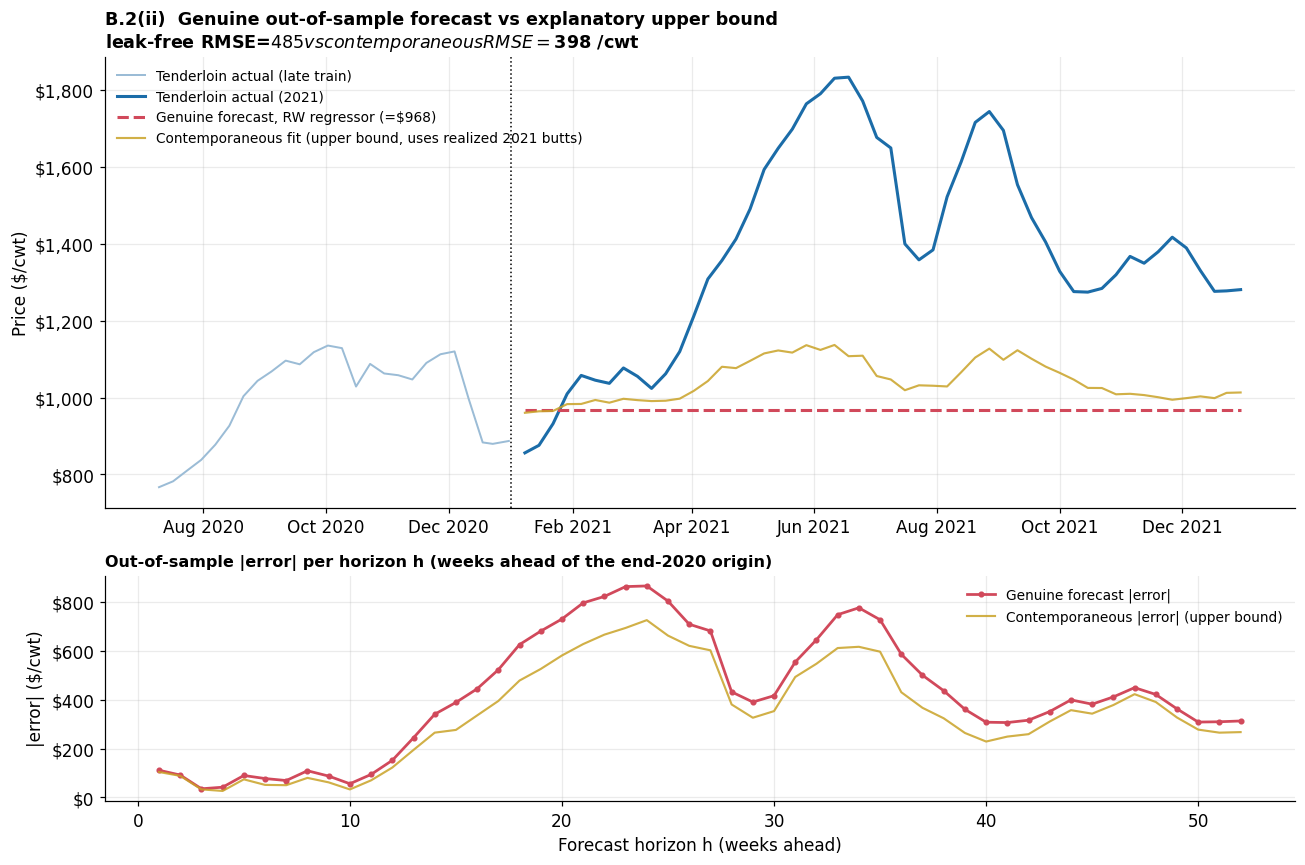

In [10]:
# (ii) GENUINE forecast, no look-ahead: random-walk the regressor from the end-2020 origin.
#      A forecaster at end-2020 does not have 2021's butt prices, so forecast them the naive
#      way (random walk = hold the last training value), then push them through the same model.
butt_last  = train.butt_bnls_price.iloc[-1]                       # last obs before the 2021 cutoff
butt_rw_sc = (butt_last - muX) / sdX                              # train-scaled, held flat across 2021
yhat_rw    = (mdl.params['const'] + mdl.params['butt_bnls_scaled'] * butt_rw_sc) * sdY + muY

test['pred_fc'] = yhat_rw                                         # genuine (leak-free) forecast, $/cwt
test['err_fc']  = test.tndrloin_price - test.pred_fc
rmse_fc = np.sqrt((test.err_fc**2).mean()); mae_fc = test.err_fc.abs().mean(); bias_fc = test.err_fc.mean()

print("Genuine h-step forecast - random-walk the regressor, only end-2020 info:")
print(f"  forecast held flat at ${yhat_rw:,.0f}/cwt across 2021")
print(f"  RMSE={rmse_fc:.0f}  MAE={mae_fc:.0f}  bias={bias_fc:+.0f}  (USD/cwt)")
print(f"  contemporaneous upper bound (uses realized 2021 butts):  RMSE={rmse:.0f}")

fig, axs = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios':[2, 1]})
axs[0].plot(train.report_date.iloc[-26:], train.tndrloin_price.iloc[-26:], color='#9bbcd6', lw=1.3, label='Tenderloin actual (late train)')
axs[0].plot(test.report_date, test.tndrloin_price, color=C['tndrloin'], lw=2.0, label='Tenderloin actual (2021)')
axs[0].plot(test.report_date, test.pred_fc, color='#d1495b', lw=2.0, ls='--', label=f'Genuine forecast, RW regressor (=${yhat_rw:,.0f})')
axs[0].plot(test.report_date, test.pred, color='#c9a227', lw=1.4, alpha=0.85, label='Contemporaneous fit (upper bound, uses realized 2021 butts)')
axs[0].axvline(pd.Timestamp('2021-01-01'), color='k', ls=':', lw=1)
axs[0].yaxis.set_major_formatter(usd)
axs[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2)); axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axs[0].set_title(f'B.2(ii)  Genuine out-of-sample forecast vs explanatory upper bound\nleak-free RMSE=${rmse_fc:.0f} vs contemporaneous RMSE=${rmse:.0f} /cwt',
                 fontweight='bold', fontsize=11.5, loc='left')
axs[0].set_ylabel('Price ($/cwt)'); axs[0].legend(frameon=False, fontsize=9, loc='upper left')

axs[1].plot(test.horizon, test.err_fc.abs(), color='#d1495b', lw=1.8, marker='o', ms=3, label='Genuine forecast |error|')
axs[1].plot(test.horizon, test.err.abs(), color='#c9a227', lw=1.4, alpha=0.85, label='Contemporaneous |error| (upper bound)')
axs[1].set_title('Out-of-sample |error| per horizon h (weeks ahead of the end-2020 origin)', fontweight='bold', fontsize=10.5, loc='left')
axs[1].set_xlabel('Forecast horizon h (weeks ahead)'); axs[1].set_ylabel('|error| ($/cwt)')
axs[1].yaxis.set_major_formatter(usd); axs[1].legend(frameon=False, fontsize=9)
plt.tight_layout(); save_plot("B2_genuine_forecast"); plt.show()


The genuine forecast is a flat line: with only end-2020 information, the model's best guess for all of 2021 is a single level. Its error climbs with horizon as tenderloin pulls away into the 2021 regime jump, the honest signature of a level model forecasting across a structural break. Stripping the look-ahead pushes RMSE above the contemporaneous upper bound, which confirms the same-week butt price, not any forward-looking power, was doing the work. This is the out-of-sample error per horizon the exercise asks for; Part C generalizes it to a rolling walk-forward and benchmarks it against naive persistence.

## C. Documenting expected accuracy going forward

Strategy: walk-forward, also called rolling-origin or time-series cross-validation (Hyndman), benchmarked against a naive baseline and discounted for model search.

To document the model's future accuracy, backtest the way the model will operate in production, always forecasting forward from past-only data.

1. Don't let it cheat. Train on the past, predict what comes next, slide forward, repeat — always using only what you'd have known at the time. Run this full test just once, at the very end.
2. Don't give one number. Give a range — best year, worst year — and show that guessing further ahead is harder. Never use the "fits the past" score to describe the future.
3. Compare to the dumb guess. Always stack it against "next week = this week." The model only counts as good if it actually beats that.
4. Don't fool yourself. The more versions you try, the more likely one looks great by pure luck — so count how many you tried and lower your accuracy claim to be safe. Quote the honest number, not the best-looking one.
5. Note its blind spots. Say whether it usually guesses too high or too low, and flag the years it breaks (like 2021, when prices jumped to a new level).
6. Keep it alive. Don't test once and forget it. Keep checking predictions against reality, keep the number updated, and set an alarm for when it drifts.

Provenance. Steps 1 through 3 and step 5 are standard time-series cross-validation. Steps 4 and 6 follow the overfitting discipline in Marcos López de Prado, Advances in Financial Machine Learning (Wiley, 2018), and Campbell Harvey and Yan Liu, "Backtesting" (Journal of Portfolio Management, 2015). Count and report the number of trials, watch degrees of freedom, discount for multiple testing, and treat expected accuracy as a living, monitored number.

Demonstrated against described: the cell below runs points 1 through 3, an expanding-window walk-forward with yearly test folds, benchmarked against last-week persistence. Points 4 and 6, the trial-count discount, degrees of freedom, bootstrap distribution, and live monitoring, are described in the strategy, not built in this notebook.

In [11]:
from scipy.stats import wilcoxon

def fit_predict(tr, te):
    mY, sY = tr.tndrloin_price.mean(), tr.tndrloin_price.std()
    mX, sX = tr.butt_bnls_price.mean(), tr.butt_bnls_price.std()
    m = sm.OLS((tr.tndrloin_price - mY) / sY,
               sm.add_constant(((tr.butt_bnls_price - mX) / sX).rename('b'))).fit()
    Xte = sm.add_constant((((te.butt_bnls_price - mX) / sX).rename('b')), has_constant='add')
    return m.predict(Xte).values * sY + mY

persist = df.tndrloin_price.shift(1)   # last-week baseline
rows = []
model_ae, naive_ae = [], []            # per-week |errors|, pooled across folds, for a paired test
for Y in range(2019, 2026):
    tr, te = df[df.year < Y], df[df.year == Y]
    if len(te) == 0:
        continue
    pred = fit_predict(tr, te); act = te.tndrloin_price.values
    nerr = act - persist.loc[te.index].values
    model_ae.extend(np.abs(act - pred)); naive_ae.extend(np.abs(nerr))
    rows.append({'test_year': Y, 'n': len(te), 'train_n': len(tr),
                 'model_RMSE': np.sqrt(np.mean((act - pred)**2)),
                 'model_MAE':  np.mean(np.abs(act - pred)),
                 'bias':       np.mean(act - pred),
                 'naive_RMSE': np.sqrt(np.nanmean(nerr**2))})
cv = pd.DataFrame(rows)
print(f"Mean model RMSE across folds: ${cv.model_RMSE.mean():.0f}  (median ${cv.model_RMSE.median():.0f})")
print(f"Mean naive (persistence) RMSE: ${cv.naive_RMSE.mean():.0f}")
print(f"Model beats naive in {int((cv.model_RMSE < cv.naive_RMSE).sum())}/{len(cv)} folds")

# paired test on per-week |errors| (model vs naive), pooled across folds (Wilcoxon signed-rank)
model_ae, naive_ae = np.array(model_ae), np.array(naive_ae)
mask = ~np.isnan(naive_ae)
stat, pval = wilcoxon(model_ae[mask], naive_ae[mask])
worse = "significantly worse" if (pval < 0.05 and np.median(model_ae[mask]) > np.median(naive_ae[mask])) else "not distinguishable"
print(f"\nPaired Wilcoxon signed-rank, |model error| vs |naive error|  (n={int(mask.sum())} weeks):")
print(f"  median |model error| = ${np.median(model_ae[mask]):.0f}   median |naive error| = ${np.median(naive_ae[mask]):.0f}")
print(f"  statistic={stat:.0f}  p={pval:.2e}  ->  model is {worse} vs naive persistence")
cv.round({'model_RMSE':0,'model_MAE':0,'bias':0,'naive_RMSE':0})

Mean model RMSE across folds: $243  (median $231)
Mean naive (persistence) RMSE: $53
Model beats naive in 0/7 folds

Paired Wilcoxon signed-rank, |model error| vs |naive error|  (n=340 weeks):
  median |model error| = $138   median |naive error| = $29
  statistic=3124  p=3.99e-46  ->  model is significantly worse vs naive persistence


,test_year,n,train_n,model_RMSE,model_MAE,bias,naive_RMSE
0,2019,52,104,135.0,77.0,53.0,38.0
1,2020,53,156,151.0,114.0,-40.0,77.0
2,2021,52,209,398.0,343.0,334.0,69.0
3,2022,52,261,231.0,174.0,157.0,53.0
4,2023,53,313,290.0,237.0,223.0,47.0
5,2024,52,366,221.0,191.0,-10.0,48.0
6,2025,26,418,277.0,232.0,-223.0,43.0


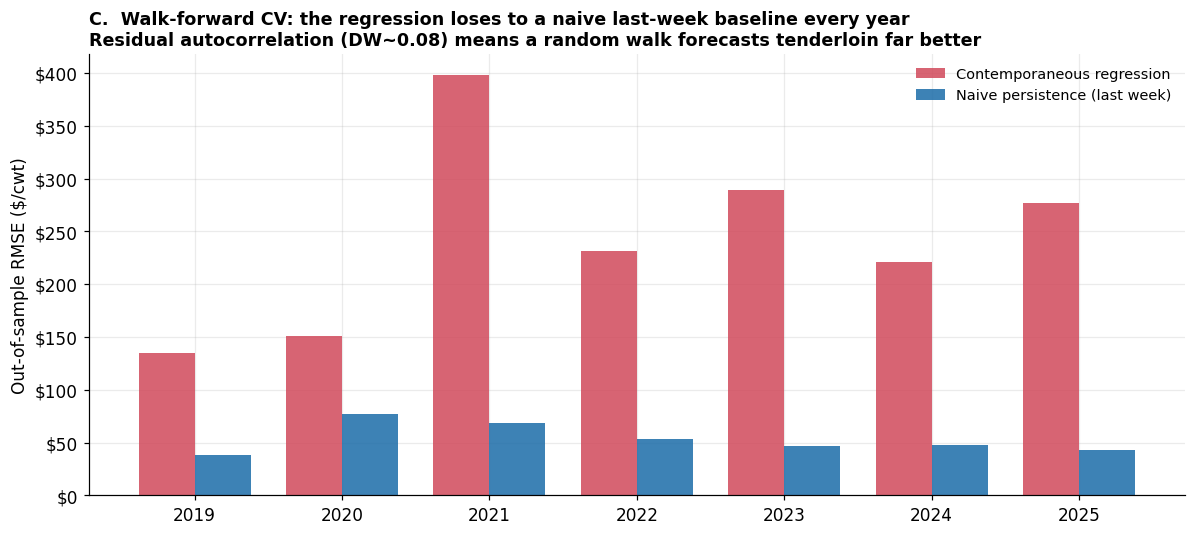

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cv)); w = 0.38
ax.bar(x - w/2, cv.model_RMSE, w, color='#d1495b', alpha=0.85, label='Contemporaneous regression')
ax.bar(x + w/2, cv.naive_RMSE, w, color='#1b6ca8', alpha=0.85, label='Naive persistence (last week)')
ax.set_xticks(x); ax.set_xticklabels(cv.test_year.astype(int))
ax.set_ylabel('Out-of-sample RMSE ($/cwt)'); ax.yaxis.set_major_formatter(usd)
ax.set_title('C.  Walk-forward CV: the regression loses to a naive last-week baseline every year\n'
             'Residual autocorrelation (DW~0.08) means a random walk forecasts tenderloin far better',
             fontweight='bold', fontsize=11.5, loc='left')
ax.legend(frameon=False, fontsize=9.5)
plt.tight_layout(); save_plot("C_walkforward_cv"); plt.show()


The headline result, and the caveat worth flagging. Across yearly walk-forward folds the model averages about \$243 RMSE, worst at \$398 in the 2021 regime year, yet the model loses to naive last-week persistence in all seven folds, where naive sits near \$53 RMSE. The baseline comparison pays off here. Even granted the same contemporaneous, look-ahead access to butt prices as B.2(i), the model still forecasts poorly, because it throws away the series' own strong week-to-week persistence, the same problem the Durbin-Watson of 0.08 in B.1 flagged. A paired Wilcoxon signed-rank test on the weekly errors points the same way (median \$138 vs \$29), though its exact p-value is anti-conservative because weekly errors are autocorrelated; the robust claim is the unanimous 7/7-fold loss and the size of that gap, not the test's headline p-value.

Recommendation. To forecast tenderloin for real, model the cut's own dynamics. Work in differences or returns, or add lagged tenderloin through an ARIMA-style or error-correction model. Keep the holiday seasonality from Part A. Document accuracy with walk-forward cross-validation, per horizon, against the random-walk and seasonal-naive baselines, with error bands instead of a single number. The contemporaneous regression works for explaining co-movement across cuts. As a standalone forecaster, no.

This notebook loads and cleans beef_data.csv directly, the same steps as Part A.